# Proyecto 1: Análisis Exploratorio de Datos (EDA) — Online Retail

**Autor:** Madelline Araya

**Objetivo del proyecto:** Explorar y limpiar un dataset real de transacciones de una tienda online del Reino Unido (2010-2011), identificar problemas de calidad de datos, y extraer hallazgos accionables sobre el comportamiento de ventas y clientes.

**Dataset:** [Online Retail — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/352/online+retail)

**Preguntas que este análisis busca responder:**
1. ¿Cuáles son los productos y países con mayores ventas?
2. ¿Cómo varían las ventas a lo largo del tiempo (estacionalidad)?
3. ¿Qué porcentaje de las transacciones son devoluciones y qué impacto tienen?
4. ¿Qué perfil tienen los clientes más valiosos (mayor gasto)?

## 1. Importar librerías y cargar los datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_excel('online_retail.xlsx')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Inspección inicial
Tenemos: Tamaño del dataset, tipos de datos, valores nulos y estadísticas básicas.

In [4]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.info()

Filas: 541909, Columnas: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
# Valores nulos por columna
df.isnull().sum().sort_values(ascending=False)

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [6]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


**Hallazgo esperado:** Se notan valores nulos en `CustomerID` y posiblemente en `Description`, y valores negativos en `Quantity.

## 3. Limpieza de datos


In [7]:
# Convertir fecha a datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Separar devoluciones (Quantity negativo) del análisis de ventas positivas
df_returns = df[df['Quantity'] < 0].copy()
df_sales = df[df['Quantity'] > 0].copy()

print(f"Líneas de venta: {len(df_sales)}")
print(f"Líneas de devolución: {len(df_returns)}")
print(f"Porcentaje de líneas de devoluciones: {len(df_returns)/len(df)*100:.2f}%")

Líneas de venta: 531285
Líneas de devolución: 10624
Porcentaje de líneas de devoluciones: 1.96%


In [13]:
# Eliminar filas con precio unitario en 0
df_sales = df_sales[df_sales['UnitPrice'] > 0]

# Crear monto total por línea de venta
df_sales['TotalPrice'] = df_sales['Quantity'] * df_sales['UnitPrice']

# Calcular el valor de las devoluciones
df_returns['ReturnValue'] = (
    df_returns['Quantity'] * df_returns['UnitPrice']
).abs()

total_sales = df_sales['TotalPrice'].sum()
total_returns = df_returns['ReturnValue'].sum()

print(f"Ventas totales: £{total_sales:,.2f}")
print(f"Valor total de devoluciones: £{total_returns:,.2f}")
print(f"Devoluciones como % de las ventas: {total_returns/total_sales*100:.2f}%")

df_sales.head()

Ventas totales: £10,666,684.54
Valor total de devoluciones: £896,812.49
Devoluciones como % de las ventas: 8.41%


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


## 4. Análisis exploratorio y visualizaciones

### 4.1 Ventas por país

/tmp/ipykernel_19362/330194486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_pais.values, y=ventas_pais.index, palette='Blues_r')


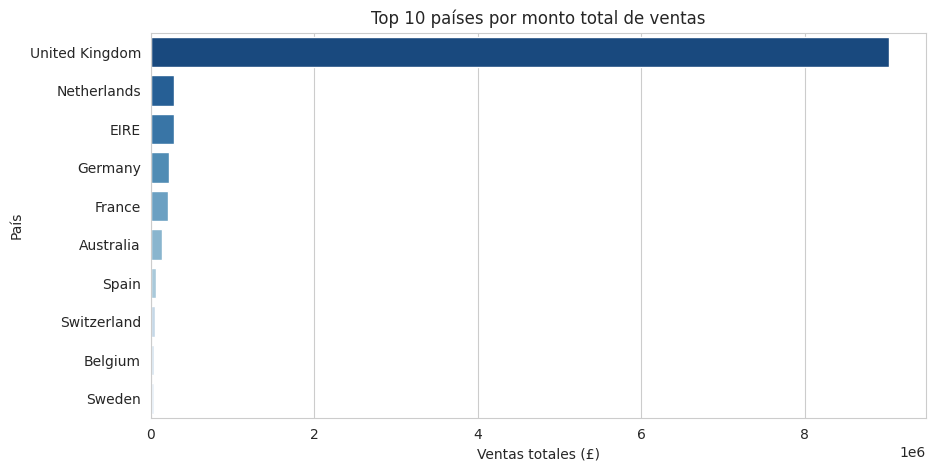

In [9]:
ventas_pais = df_sales.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=ventas_pais.values, y=ventas_pais.index, palette='Blues_r')
plt.title('Top 10 países por monto total de ventas')
plt.xlabel('Ventas totales (£)')
plt.ylabel('País')
plt.show()

### 4.2 Productos más vendidos

/tmp/ipykernel_19362/2781762019.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_productos.values, y=top_productos.index, palette='Greens_r')


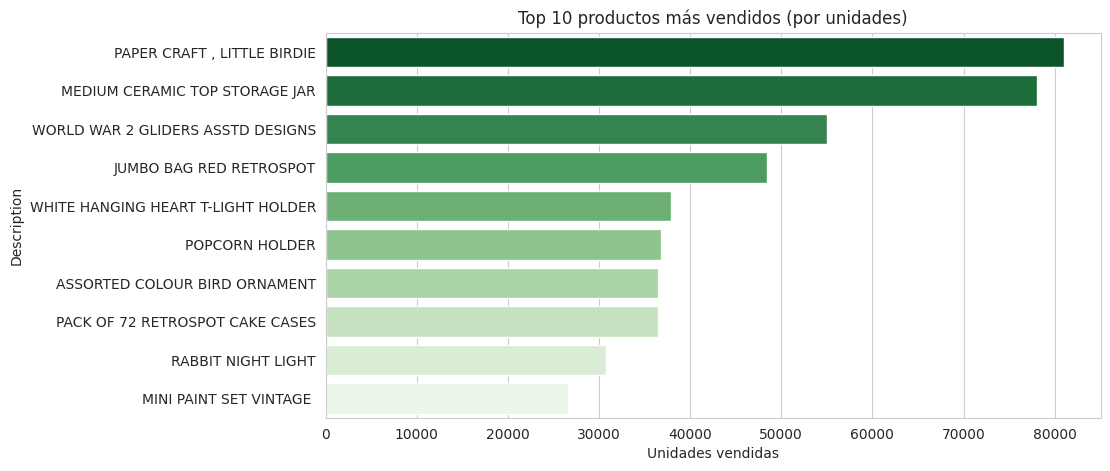

In [10]:
top_productos = df_sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_productos.values, y=top_productos.index, palette='Greens_r')
plt.title('Top 10 productos más vendidos (por unidades)')
plt.xlabel('Unidades vendidas')
plt.show()

### 4.3 Estacionalidad de ventas (por mes)

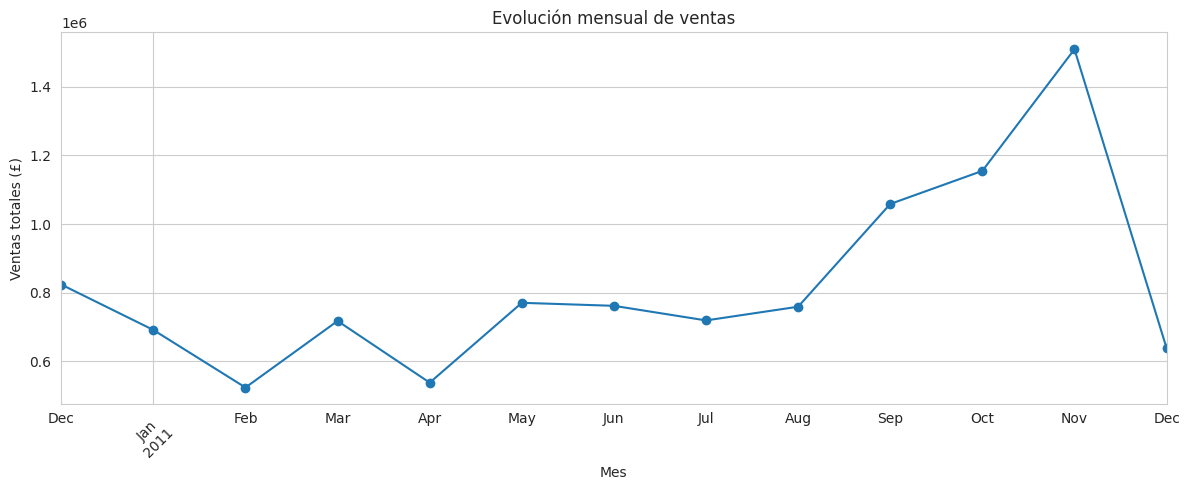

In [11]:
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
ventas_mes = df_sales.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
ventas_mes.plot(kind='line', marker='o')
plt.title('Evolución mensual de ventas')
plt.xlabel('Mes')
plt.ylabel('Ventas totales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4.4 Clientes más valiosos (Top 10 por gasto total)

/tmp/ipykernel_19362/3414230099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_clientes.values, y=top_clientes.index.astype(int).astype(str), palette='Oranges_r')


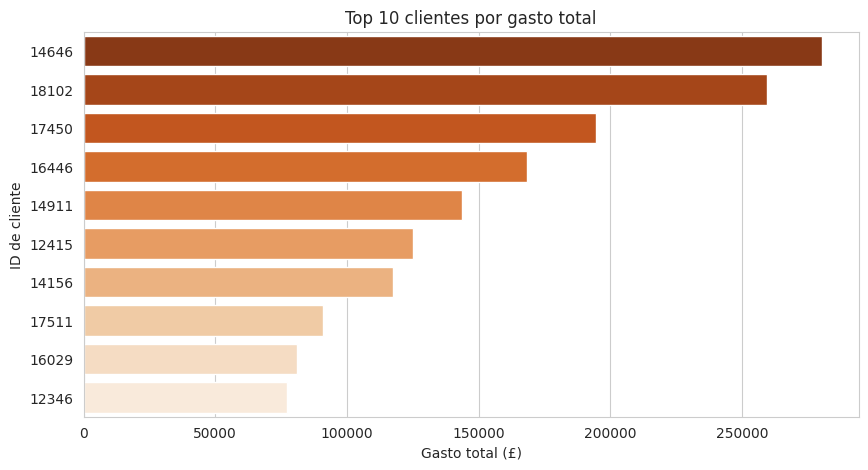

In [12]:
top_clientes = df_sales.dropna(subset=['CustomerID']).groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_clientes.values, y=top_clientes.index.astype(int).astype(str), palette='Oranges_r')
plt.title('Top 10 clientes por gasto total')
plt.xlabel('Gasto total (£)')
plt.ylabel('ID de cliente')
plt.show()

## 5. Hallazgos principales

1. **País líder en ventas:** Reino Unido concentra el 84.61% de las ventas totales, con aproximadamente £9.03 millones de los £10.67 millones en ventas positivas. Esto muestra una fuerte concentración de las ventas en el mercado británico y podría representar una oportunidad para analizar el potencial de otros mercados.

2. **Estacionalidad:** Las ventas muestran su mayor pico en noviembre de 2011, con aproximadamente £1.51 millones. También se observa un crecimiento en los meses anteriores. Este comportamiento podría estar relacionado con un aumento de las compras previo a la temporada navideña, aunqie sería necesario contar con información adicional para confirmar esta hipótesis.

3. **Devoluciones:** Las devoluciones representan el 1.96% de las líneas del dataset. Sin embargo, su impacto económico es mayor, ya que el valor de las devoluciones alcanza aproximadamente £896,812, equivalente al 8.41% del valor de las ventas positivas. La mayoría de las líneas de devolución corresponden al Reino Unido (86.52%), aunque esto también está relacionado con el peso de este país en las ventas totales.

4. **Concentración de clientes:** Las devoluciones representan el 1.96% de las líneas del dataset. Sin embargo, su impacto económico es mayor, ya que el valor de las devoluciones alcanza aproximadamente £896,812, equivalente al 8.41% del valor de las ventas positivas. La mayoría de las líneas de devolución corresponden al Reino Unido (86.52%), aunque esto también está relacionado con el peso de este país en las ventas totales.

## 6. Qué haría diferente / próximos pasos
- Cruzar este análisis con un proyecto de SQL para validar los hallazgos con consultas independientes.
- Explorar un análisis de cohortes o RFM (Recencia, Frecuencia, Monto) para segmentar clientes.
- Construir el dashboard en Power BI/Tableau usando estas mismas métricas.